In [10]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os
from pydantic import BaseModel,Field
import  operator
load_dotenv()

True

In [2]:
# LLM Configuration - DeepSeek R1 Distill Qwen 7B
LLAMA_STUDIO_API_BASE = os.getenv("LLAMA_STUDIO_API_BASE", "http://localhost:1234/v1")
LLAMA_STUDIO_API_KEY = os.getenv("LLAMA_STUDIO_API_KEY", "lm-studio")
LLM_MODEL_NAME = os.getenv("LLM_MODEL_NAME", "deepseek-r1-distill-qwen-7b")
LLM_TEMPERATURE = float(os.getenv("LLM_TEMPERATURE", "0.7"))
LLM_MAX_TOKENS = int(os.getenv("LLM_MAX_TOKENS", "2048"))
LLM_TIMEOUT = int(os.getenv("LLM_TIMEOUT", "60"))  # Timeout in seconds
LLM_MAX_RETRIES = int(os.getenv("LLM_MAX_RETRIES", "2"))  # Number of retries

In [3]:
model = ChatOpenAI(
        base_url=LLAMA_STUDIO_API_BASE,
        api_key=LLAMA_STUDIO_API_KEY,
        model=LLM_MODEL_NAME,
        temperature=LLM_TEMPERATURE,
        max_tokens=LLM_MAX_TOKENS,
        timeout=LLM_TIMEOUT,
        max_retries=LLM_MAX_RETRIES,
      
    )

In [17]:
essay="""Artificial Intelligence in Pakistan: Challenges, Opportunities, and the Road Ahead

Artificial Intelligence (AI) is rapidly transforming the global landscape, reshaping industries, education, and governance. In Pakistan, AI has emerged as both a challenge and an opportunity — a chance to modernize the economy, strengthen governance, and empower youth with new digital skills. While progress is visible, the nation still faces substantial obstacles that need to be addressed for AI to reach its full potential.

The Rise of AI Awareness in Pakistan

AI gained national attention in Pakistan during the late 2010s when global discussions on automation and data-driven decision-making began influencing local academic and policy circles. In 2018, Pakistan’s Ministry of Information Technology and Telecommunication launched the National Center of Artificial Intelligence (NCAI), hosted by leading universities such as NUST, UET Peshawar, and COMSATS. This initiative marked a significant step toward fostering research and development in AI-related domains like robotics, natural language processing, and data science.

Applications of AI in Key Sectors

AI applications are gradually taking root in several key sectors of Pakistan’s economy:

Healthcare – AI-driven diagnostic tools are helping doctors analyze X-rays and patient data more efficiently. Startups like Sehat Kahani and Marham are exploring predictive healthcare models and telemedicine, especially for rural populations.

Agriculture – Precision agriculture using satellite data and machine learning models is helping farmers predict crop yields, identify pest infestations, and manage irrigation systems more effectively.

Education – AI-powered platforms are improving digital learning experiences through personalized content and assessment tools. Universities are also introducing AI-related courses and degrees to prepare students for the Fourth Industrial Revolution.

Governance and Security – AI technologies are increasingly used in facial recognition, traffic monitoring, and predictive policing. The Punjab Safe Cities Authority (PSCA) is one of the prominent examples of integrating AI for public safety.

Finance and E-commerce – Banks and fintech companies are using AI for fraud detection, customer service chatbots, and personalized financial solutions.

Challenges and Limitations

Despite its potential, the adoption of AI in Pakistan faces several significant barriers:

Lack of Infrastructure: Limited access to high-performance computing facilities and reliable internet connectivity restricts large-scale AI experimentation.

Skill Gap: There is a shortage of skilled professionals in data science, machine learning, and AI engineering. Many graduates lack hands-on exposure to real-world AI applications.

Data Scarcity and Quality: AI systems depend on high-quality datasets, but Pakistan lacks open data repositories and structured data policies.

Policy and Regulation: The absence of a comprehensive AI policy framework slows down innovation while raising ethical concerns about privacy, surveillance, and job displacement.

Government and Private Sector Initiatives

Encouragingly, both the public and private sectors have begun to recognize AI’s strategic importance. The Pakistan National AI Policy 2023 draft emphasizes developing a skilled workforce, promoting AI research centers, and supporting startups. Organizations like Ignite (National Technology Fund) are funding AI-driven innovation projects. Meanwhile, private ventures, tech incubators, and university collaborations are building local AI ecosystems.

The Way Forward

To fully harness AI’s potential, Pakistan must prioritize the following steps:

Education and Capacity Building: Introducing AI-focused curricula at school and university levels will cultivate a generation ready for AI-driven industries.

Public-Private Collaboration: Encouraging cooperation between academia, startups, and government can accelerate research commercialization.

Infrastructure Investment: Cloud computing centers and open data platforms are essential to support large-scale AI projects.

Ethical and Regulatory Frameworks: Responsible AI governance will ensure fairness, transparency, and accountability in AI applications.

Conclusion

AI holds the promise of reshaping Pakistan’s future — from smart agriculture and healthcare innovation to efficient governance and inclusive education. However, realizing this promise requires coordinated efforts across education, industry, and policy. With its young and dynamic population, Pakistan has the potential to not only adopt AI but also become a regional hub of innovation. The journey has begun; the challenge now is to sustain it with vision, ethics, and strategic commitment."""

In [6]:
class EvaluationSchema(BaseModel):
    feedback:str = Field(description='Detailed feedback for the essay')
    score:int = Field(description='Score out of 10',ge=0,le=10)
str_model = model.with_structured_output(EvaluationSchema)

In [8]:
prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}'
str_model.invoke(prompt).score

8

In [19]:
#define state   
class UPSCState(TypedDict):
    essay:str
    language_feedback:str
    analysis_feedback:str
    clarity_feedback:str
    overall_feedback:str
    individual_scores:Annotated[list[int],operator.add]
    avg_score:float
    


In [20]:
def evaluate_language(state:UPSCState) -> UPSCState:

    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}'
    # call lllm for outline 
    output = str_model.invoke(prompt)

    return {'language_feedback':output.feedback,'individual_scores':[output.score]}

def evaluate_analysis(state:UPSCState) -> UPSCState:
    prompt = f'Evaluate the language analysis of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}'
    # call lllm for outline 
    output = str_model.invoke(prompt)

    return {'analysis_feedback':output.feedback,'individual_scores':[output.score]}
def evaluate_thought(state:UPSCState) -> UPSCState:
    prompt = f'Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}'
    # call lllm for outline 
    output = str_model.invoke(prompt)
    
    return {'clarity_feedback':output.feedback,'individual_scores':[output.score]}

def final_evaluation(state:UPSCState) -> UPSCState:

    # summary feedback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
    overall_feedback = model.invoke(prompt).content

    # avg calculate
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}



In [21]:
# define graph 
graph = StateGraph(UPSCState)

# add nodes
graph.add_node('evaluate_language',evaluate_language)
graph.add_node('evaluate_thought',evaluate_thought)
graph.add_node('evaluate_analysis',evaluate_analysis)
graph.add_node('final_evaluation',final_evaluation)




# add edges to graph 
graph.add_edge(START,'evaluate_language')
graph.add_edge(START,'evaluate_thought')
graph.add_edge(START,'evaluate_analysis')


graph.add_edge('evaluate_language','final_evaluation')
graph.add_edge('evaluate_thought','final_evaluation')
graph.add_edge('evaluate_analysis','final_evaluation')
graph.add_edge('final_evaluation',END)

#compile the graph 
workflow = graph.compile()

# execute the graph

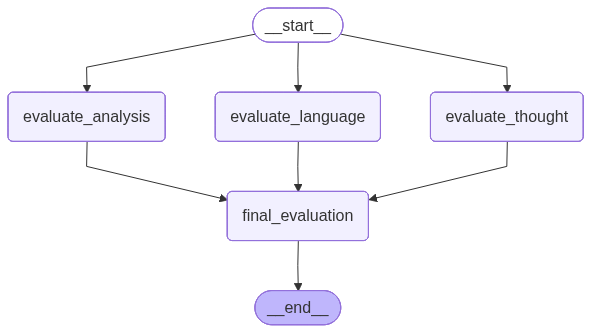

In [22]:
workflow

In [24]:
essay2 ="""AI in Pakistan

Artificial intelligence in Pakistan is now becoming big thing but still many problem in way. People now start know about AI and how it can change everything in country but not many using it proper. Pakistan try to go modern with AI but progress is slow because of less resources and low awareness.

In start some university and government make center like National Center of Artificial Intelligence (NCAI) for research. They do some work on robot and machine learning but not reach big success yet. Many student study AI but most not get job or experience to work on real project.

AI can help in many place in Pakistan. In hospital it can help doctor see disease fast. In farm AI can tell farmer when to water and how to protect crop. In education student can use AI app to learn better. Police and traffic department use camera and AI to catch people who break rule. Bank also use AI to stop fraud and talk to customer with chatbot.

But also there is many problem. Internet not good in many area, computer system not powerful, and data not clean. People not have enough skill for AI and many university still teach old stuff. There is also no clear law how to use AI, so privacy and job fear problem come.

Government say they make AI policy but still in paper. Some company and startup try to do good thing with AI but not enough support. For future Pakistan need to teach more AI in school, make more research lab, and work together between student, company and government. They also need to make good rule for AI so people can trust it.

In end, AI can make Pakistan strong if people work hard and plan good. Pakistan have young people who can do big things if given chance and tools. AI future in Pakistan is possible but still far to go."""

In [25]:
intital_state = {'essay':essay2}
workflow.invoke(intital_state)

{'essay': 'AI in Pakistan\n\nArtificial intelligence in Pakistan is now becoming big thing but still many problem in way. People now start know about AI and how it can change everything in country but not many using it proper. Pakistan try to go modern with AI but progress is slow because of less resources and low awareness.\n\nIn start some university and government make center like National Center of Artificial Intelligence (NCAI) for research. They do some work on robot and machine learning but not reach big success yet. Many student study AI but most not get job or experience to work on real project.\n\nAI can help in many place in Pakistan. In hospital it can help doctor see disease fast. In farm AI can tell farmer when to water and how to protect crop. In education student can use AI app to learn better. Police and traffic department use camera and AI to catch people who break rule. Bank also use AI to stop fraud and talk to customer with chatbot.\n\nBut also there is many proble

## The Rise of AI in Pakistan: Opportunities, Challenges, and Future Potential

**(Image: A modern image depicting technology merging with Pakistani culture – e.g., a digital representation of a farmer using an AI-powered tool in a field.)**

Artificial intelligence is rapidly transforming industries worldwide, and Pakistan is poised to be a key player in this revolution. From self-driving cars to personalized medicine, AI’s influence is undeniable. But what does the future hold for artificial intelligence within Pakistan? This blog post dives deep into the current landscape of AI adoption, explores its immense opportunities, tackles the challenges hindering progress, and envisions the potential for AI to shape Pakistan's future.  We'll cover everything from healthcare advancements to economic growth drivers – painting a comprehensive picture of where Pakistan stands and where it’s headed in this exciting field.



**II. The Current Landscape of AI in Pakistan (Approx. 350 words)**

AI

In [9]:
print(final_state['evalaute'])

## Blog Post Rating: 9.5/10

**Here's a breakdown of why it's so good and areas where it excels:**

**Strengths:**

*   **Comprehensive & Detailed:** The outline is extremely thorough, covering all the necessary aspects of AI in Pakistan – from opportunities to challenges and future potential.  The detail provided throughout the draft makes it highly credible and well-researched.
*   **Well-Structured & Organized:** The logical flow of information is excellent. Each section builds upon the previous one, providing a cohesive narrative. 
*   **Clear & Accessible Language:**  The language used is easy to understand for a general audience, avoiding technical jargon where possible.  It balances accessibility with depth.
*   **Actionable Insights:** The "Call to Action" adds a nice touch and encourages reader engagement.
*   **Addresses Key Considerations:** Includes the crucial reminder about data availability, talent gaps, ethical concerns, and regulatory frameworks – all critical areas fo

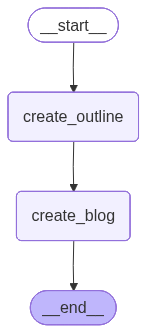

In [9]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())